# Walmart Sales Analysis: Central Limit Theorem & Confidence Intervals

## Project Overview

This project analyzes Walmart customer purchase data using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis covers data cleaning, exploratory data analysis, the Central Limit Theorem (CLT), sampling distributions, and confidence intervals to understand customer purchase behavior across different demographic groups.

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import binom
from scipy.stats import expon
from scipy.stats import norm
from scipy.stats import geom
import seaborn as sns

In [84]:
df = pd.read_csv('/content/walmart_data[1].csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


###Data Type Description

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [86]:
df.shape

(550068, 10)

###Missing Value

In [87]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


###No Missing Value

In [88]:
q3=df['Purchase'].quantile(0.75)
q1=df['Purchase'].quantile(0.25)
iqr = q3-q1
print(q3,q1,iqr)

12054.0 5823.0 6231.0


In [89]:
df_outlier = df[(df['Purchase']<q1-(1.5*iqr)) | (df['Purchase']>q3+(1.5*iqr))]
df_outlier.shape

(2677, 10)

In [90]:
df_outlier.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
343,1000058,P00117642,M,26-35,2,B,3,0,10,23603
375,1000062,P00119342,F,36-45,3,A,1,0,10,23792
652,1000126,P00087042,M,18-25,9,B,1,0,10,23233
736,1000139,P00159542,F,26-35,20,C,2,0,10,23595
1041,1000175,P00052842,F,26-35,2,B,1,0,10,23341


### Calculating percentage of outliers

In [91]:
outlier_percent=(df_outlier.shape[0]/df.shape[0])*100
outlier_percent

0.4866671029763593

### since outlier percentage is very low we can safely drop those columns to not affect the mean

In [92]:
df_new=df[~((df['Purchase']<q1-(1.5*iqr)) | (df['Purchase']>q3+(1.5*iqr)))]
df_new.shape

(547391, 10)

### Let's check the purchase amount histogram for outliers

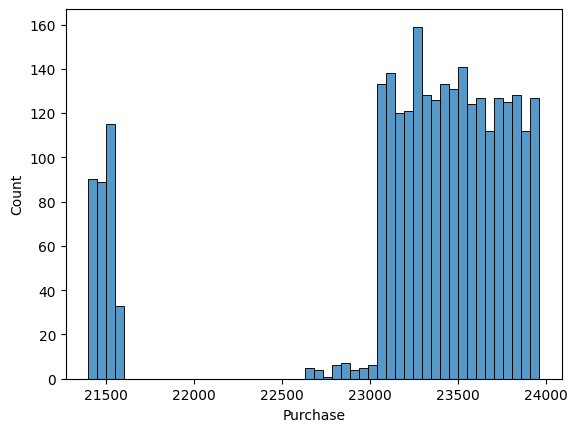

In [93]:
sns.histplot(x=df_outlier['Purchase'],bins=50)
plt.show()

### Purchase amount histogram for non outliers


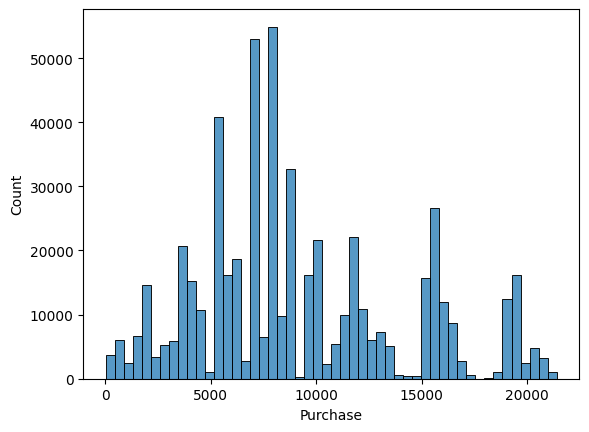

In [94]:
sns.histplot(x=df_new['Purchase'],bins=50)
plt.show()

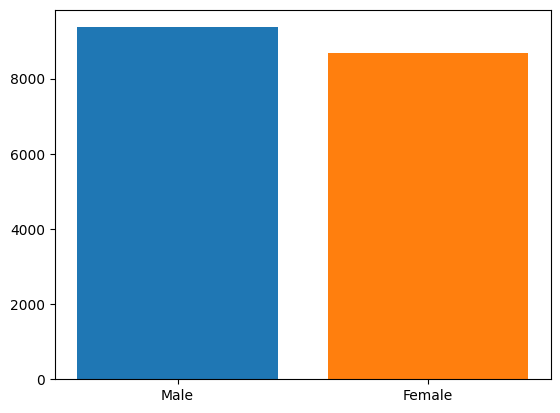

In [95]:
fig,ax=plt.subplots()
ax.bar("Male",df_new[df_new['Gender']=='M']['Purchase'].mean())
ax.bar("Female",df_new[df_new['Gender']=='F']['Purchase'].mean())
plt.show()

In [96]:
df_new.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [97]:
df_new['Occupation']=df_new['Occupation'].astype('category')

/tmp/ipykernel_626/2764232036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Occupation']=df_new['Occupation'].astype('category')


In [98]:
df_new['Stay_In_Current_City_Years'].value_counts()

,count
Stay_In_Current_City_Years,
1,192845
2,101384
3,94804
4+,84322
0,74036


### Let's plot a boxplot for all the attributes vs Purchase (Target variable)

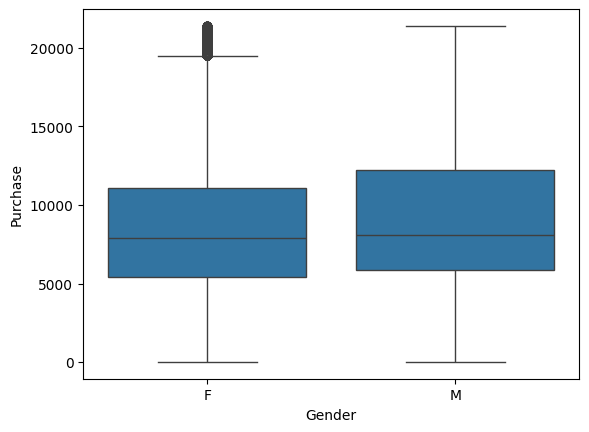

In [99]:
attributes=['Gender','Age','Occupation','City_Category','Stay_In_Current_City_Years','Marital_Status']

def plot_box(row,col,data):
    sns.boxplot(x=row,y=col,data=data)
    plt.show()

# Boxplot for Gender
plot_box(df_new['Gender'],df_new['Purchase'],df_new)

### For loop for creating all the boxplots

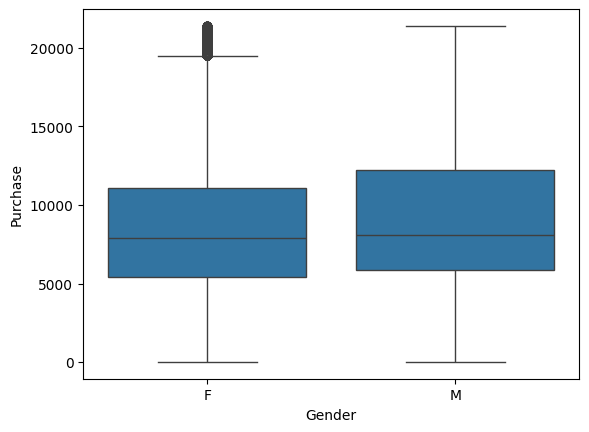

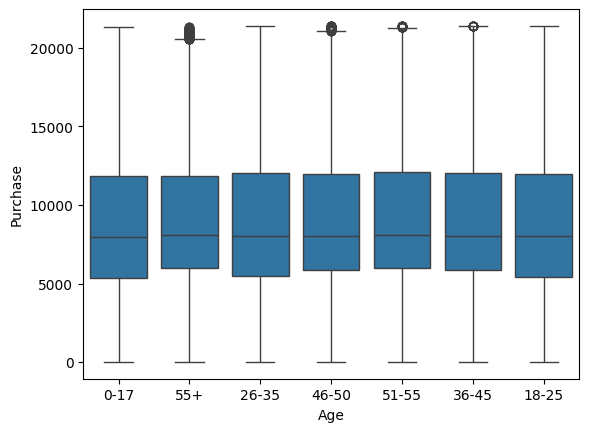

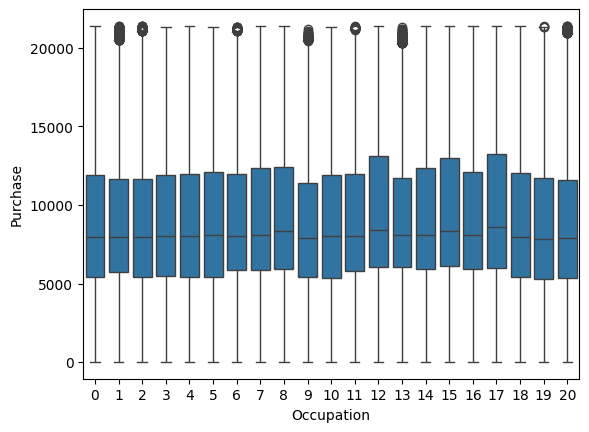

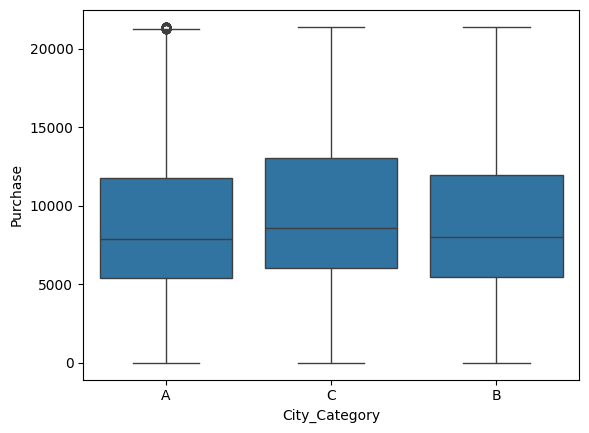

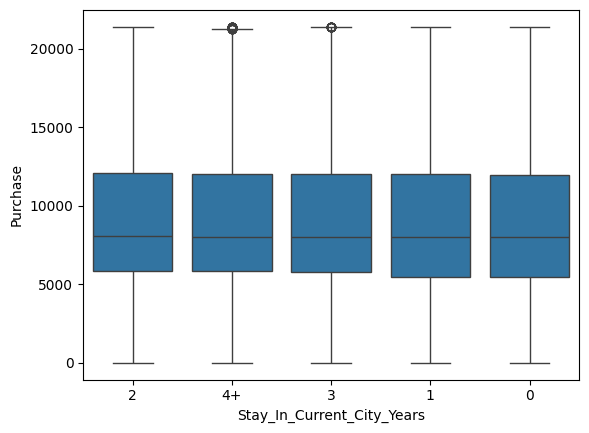

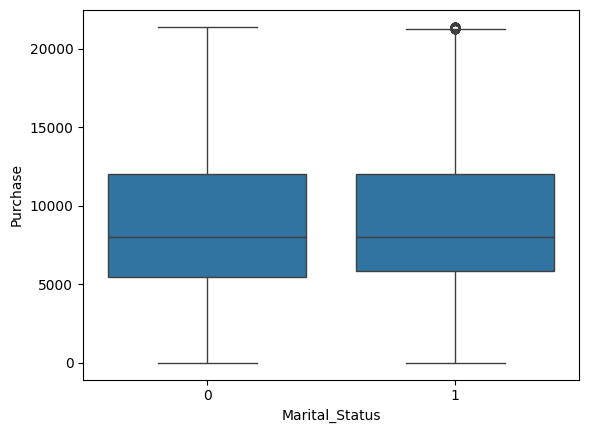

In [100]:
for i in attributes:
    plot_box(df_new[i],df_new['Purchase'],df_new)

### As the above one is little cumbersome, we will try plotting in subplots for more clear view ##


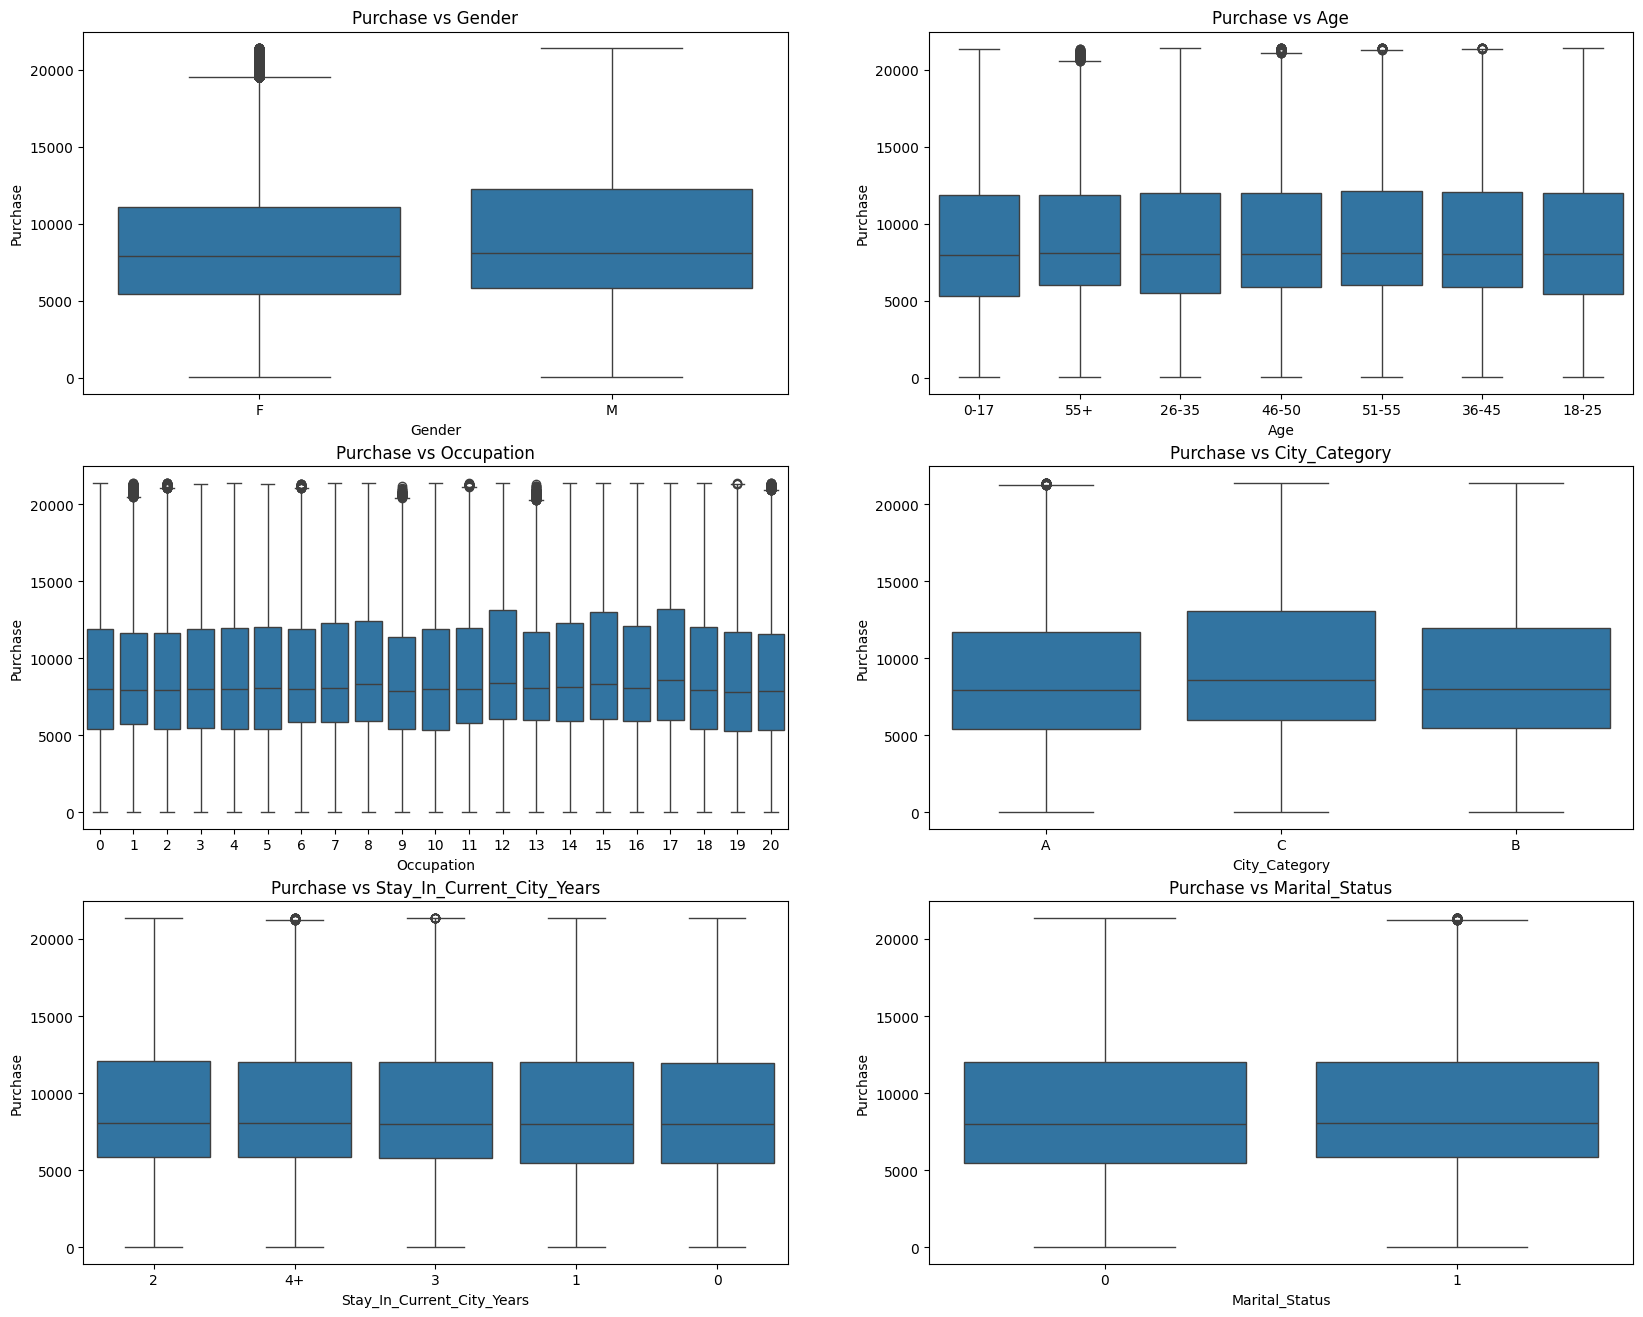

In [101]:
attributes=['Gender','Age','Occupation','City_Category','Stay_In_Current_City_Years','Marital_Status']
fig,axes=plt.subplots(3,2,figsize=(20,16))
counter=0
for i in range(3):
    for j in range(2):
        sns.boxplot(data=df_new,y='Purchase',x=attributes[counter],ax=axes[i,j])
        axes[i,j].set_title(f"Purchase vs {attributes[counter]}",)
        counter=counter+1
plt.show()

In [102]:
df=df_new

### Statistical summary of the dataset

In [103]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,547391.0,NaN,NaN,NaN,1003028.432583,1727.356809,1000001.0,1001516.0,1003075.0,1004478.0,1006040.0
Product_ID,547391,3631,P00265242,1880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,547391,2,M,412171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,547391,7,26-35,218661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,547391.0,21.0,4.0,72040.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City_Category,547391,3,B,230114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stay_In_Current_City_Years,547391,5,1,192845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,547391.0,NaN,NaN,NaN,0.409486,0.491739,0.0,0.0,0.0,1.0,1.0
Product_Category,547391.0,NaN,NaN,NaN,5.378945,3.927383,1.0,1.0,5.0,8.0,20.0
Purchase,547391.0,NaN,NaN,NaN,9195.627195,4938.872953,12.0,5721.0,8038.0,12019.0,21399.0


In [104]:
df['User_ID'].nunique()

5891

In [105]:
df['Gender'].value_counts()

,count
Gender,
M,412171
F,135220


In [106]:
percentage_male=len(df[df['Gender']=='M'])/len(df)
percentage_female=len(df[df['Gender']=='F'])/len(df)
print(percentage_male,percentage_female)

0.7529736513753423 0.2470263486246577


### Percentage of each category of data for categorical columns

In [107]:
attributes=['Gender','Age','Occupation','City_Category','Stay_In_Current_City_Years','Marital_Status']

melted_df=pd.melt(df[attributes], var_name='Variable', value_name='Value')
melted_df=melted_df.groupby(['Variable','Value'])[['Value']].count()*100/len(df)
melted_df=pd.DataFrame(melted_df)
melted_df

Value
Variable                   Value           
Age                        0-17    2.746117
                           18-25  18.146809
                           26-35  39.946035
                           36-45  19.987358
                           46-50   8.301561
                           51-55   6.976914
                           55+     3.895205
City_Category              A      26.861238
                           B      42.038324
                           C      31.100438
Gender                     F      24.702635
                           M      75.297365
Marital_Status             0      59.051391
                           1      40.948609
Occupation                 0      12.661882
                           1       8.617971
                           2       4.829272
                           3       3.209406
                           4      13.160611
                           5       2.216514
                           6       3.701376
                           7      10.755566
                           8       0.281335
                           9       1.146895
                           10      2.354441
                           11      2.100875
                           12      5.662315
                           13      1.400644
                           14      4.964093
                           15      2.207928
                           16      4.612973
                           17      7.280902
                           18      1.204806
                           19      1.536744
                           20      6.093451
Stay_In_Current_City_Years 0      13.525250
                           1      35.229845
                           2      18.521313
                           3      17.319247
                           4+     15.404345

### Insights from above operation
*  75% are male
*  most of the customers stay in the current city from 1 year
*  almost 60% of people are unmarried
*  almost 60% of people are between 25-45

### Since it's difficult to observe data like this let's plot a countplot

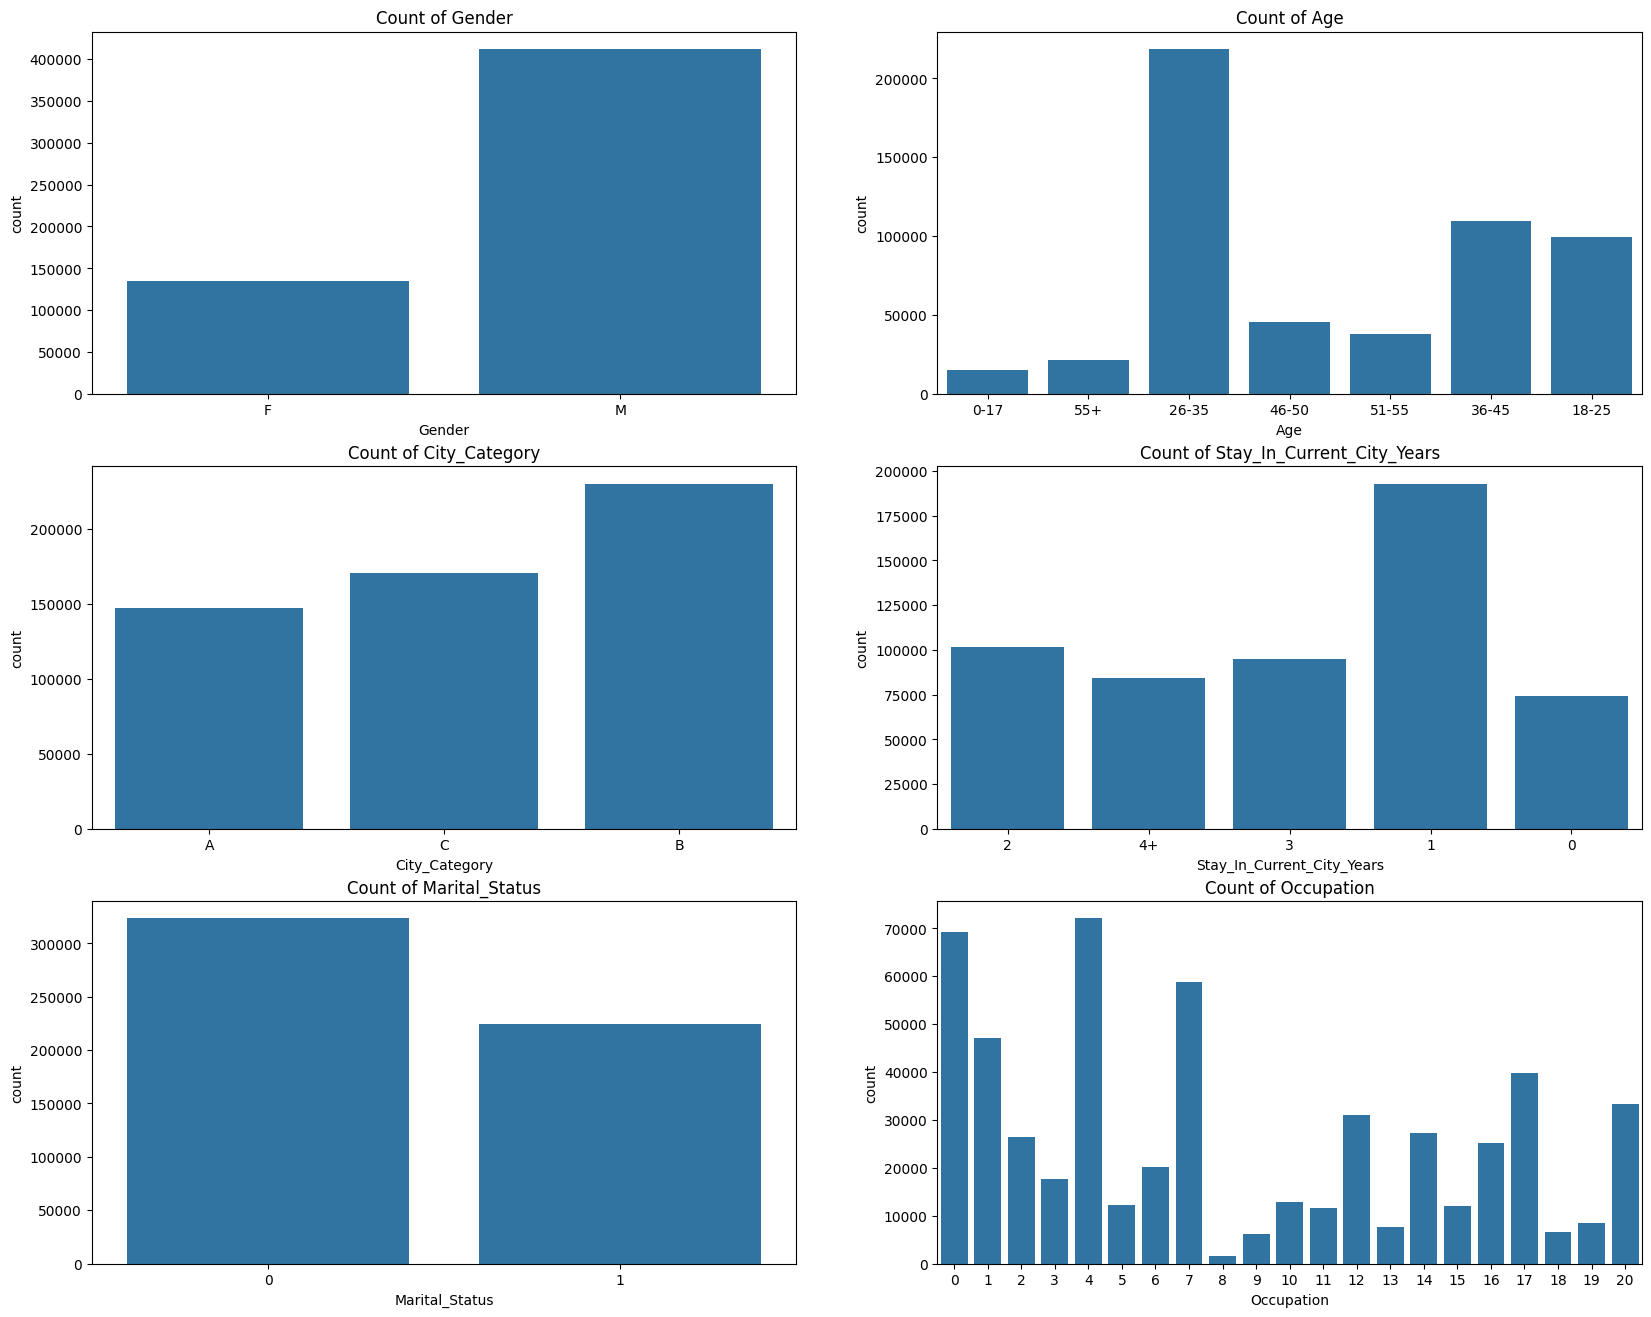

In [108]:
categories=['Gender','Age','City_Category','Stay_In_Current_City_Years','Marital_Status','Occupation']
fig,axes=plt.subplots(3,2,figsize=(20,16))
count=0
for i in range(3):
    for j in range(2):
        sns.countplot(data=df,x=categories[count],ax=axes[i,j])
        axes[i,j].set_title(f"Count of {categories[count]}")
        count=count+1

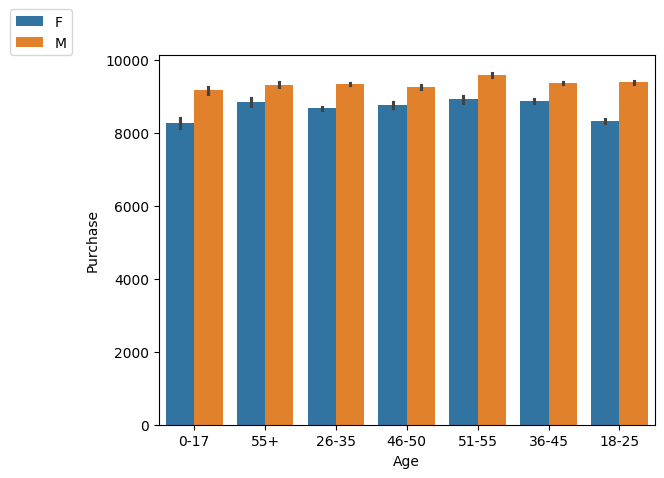

In [109]:
sns.barplot(data=df,x='Age',y='Purchase',hue='Gender')
plt.legend(loc=(-0.3,1))

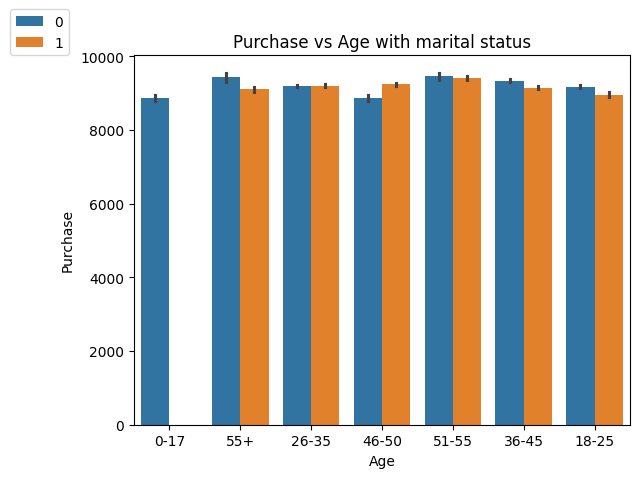

In [110]:
sns.barplot(data=df,x='Age',y='Purchase',hue='Marital_Status')
plt.title('Purchase vs Age with marital status')
plt.legend(loc=(-0.25,1))
plt.show()

### Let's now see which product is being ordered the most #


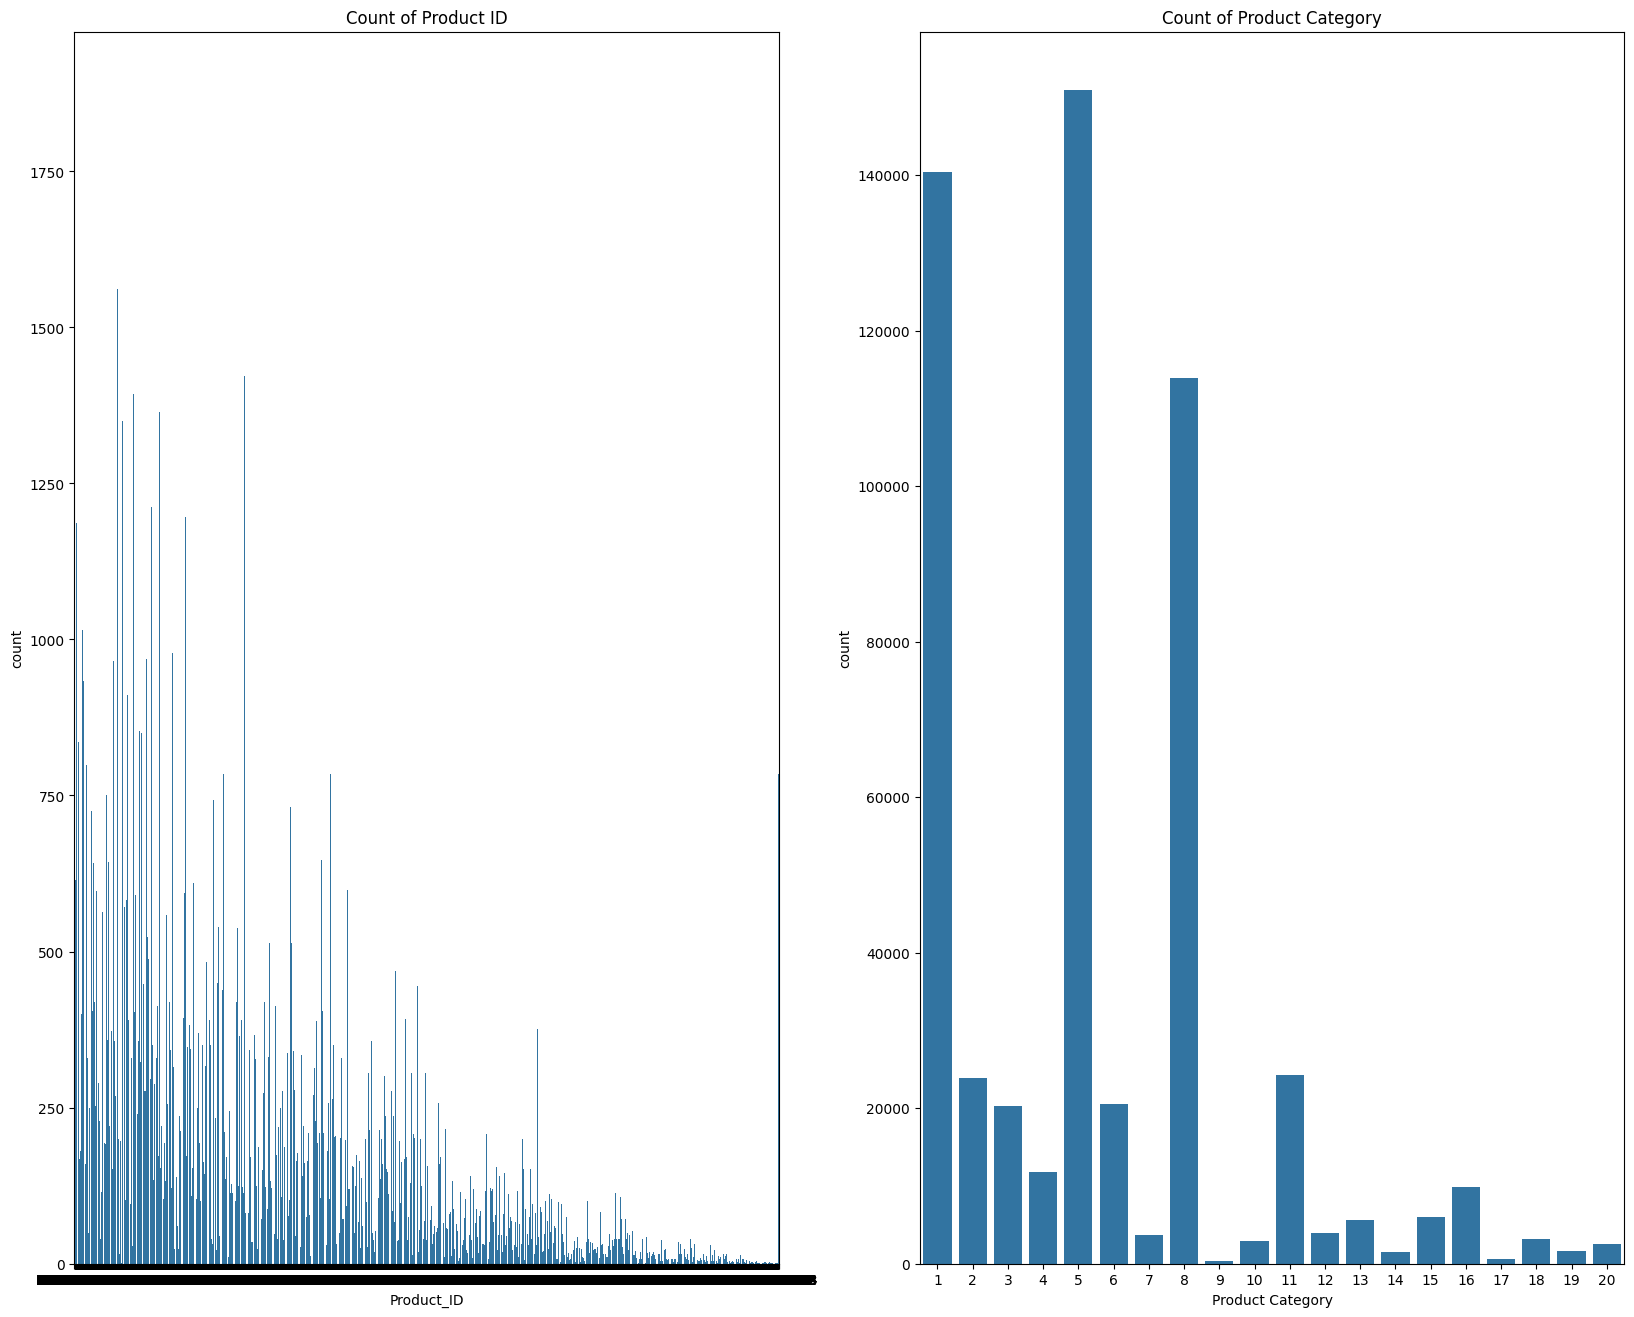

In [111]:
fig,axes=plt.subplots(1,2,figsize=(20,16))
sns.countplot(data=df,x='Product_Category',ax=axes[1])
sns.countplot(data=df,x='Product_ID',ax=axes[0])
axes[0].set_title("Count of Product ID")
axes[1].set_title("Count of Product Category")
axes[0].set_xlabel("Product_ID")
axes[1].set_xlabel("Product Category")
plt.show()

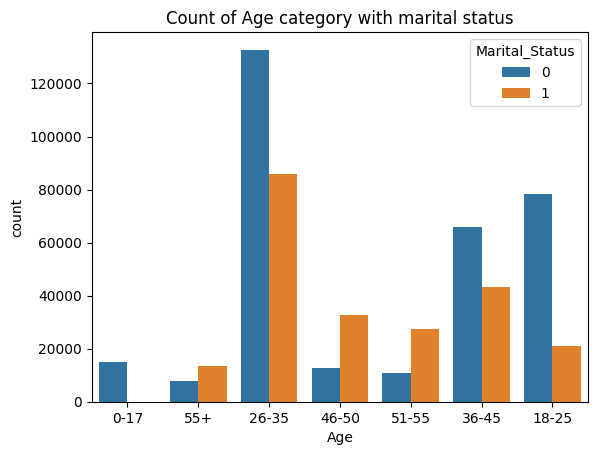

In [112]:
sns.countplot(data=df,x='Age',hue='Marital_Status')
plt.title("Count of Age category with marital status")
plt.show()

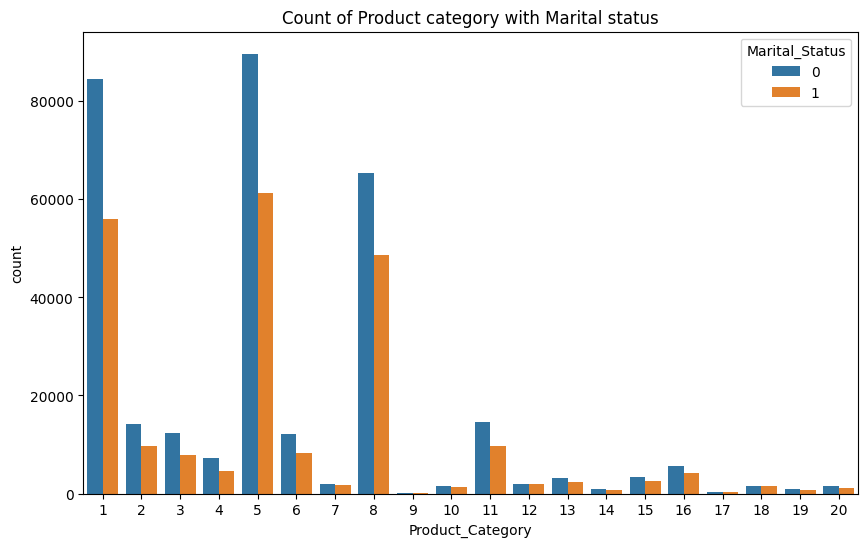

In [113]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='Product_Category',hue='Marital_Status')
plt.title("Count of Product category with Marital status")
plt.show()

### Let's now check the Purchase pattern with respect to gender


In [114]:
df.groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,135220.0,8671.049039,4679.058483,12.0,5429.0,7906.0,11064.0,21398.0
M,412171.0,9367.724355,5009.234088,12.0,5852.0,8089.0,12247.0,21399.0


In [115]:
df.sample(600).groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,150.0,8587.380000,5022.864012,36.0,5342.75,7884.0,10031.25,20978.0
M,450.0,9001.304444,4817.685723,38.0,5842.25,7891.5,11801.25,21224.0


In [116]:
matrix=df.select_dtypes('number').corr()

Actually correlation should be applied on continous numerical columns, but I am simply applying here for categorical type of columns which are numerical in nature

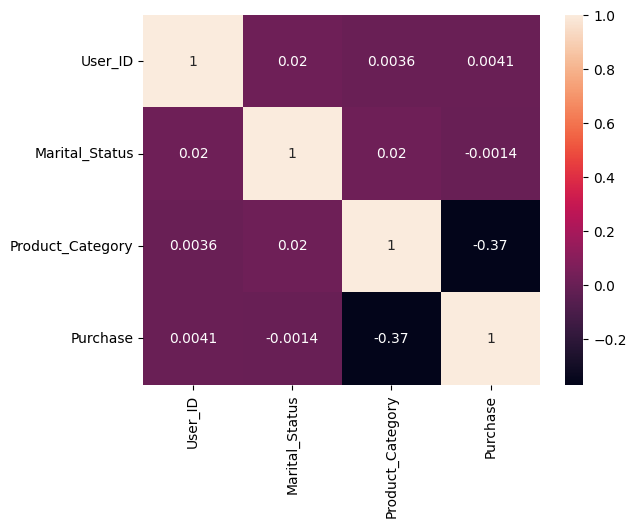

In [117]:
sns.heatmap(matrix,annot=True)
plt.show()

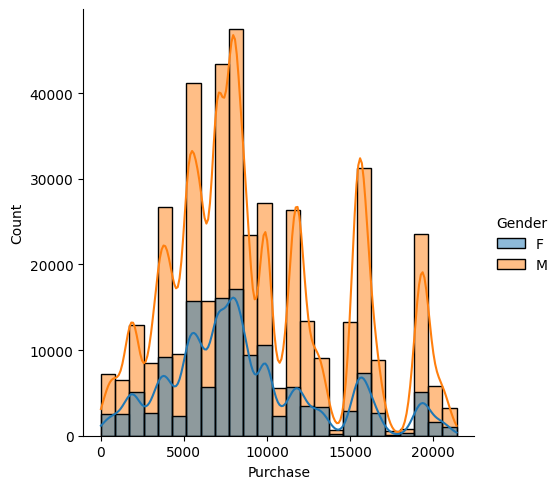

In [118]:
sns.displot(data=df,hue='Gender',bins=25, kde=True,x='Purchase' )
plt.show()

### Let's plot mean of male purchases and female purchases

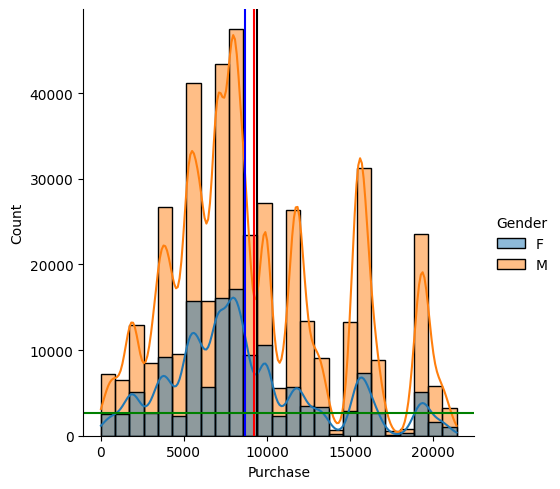

In [119]:
sns.displot(data=df,hue='Gender',bins=25, kde=True,x='Purchase' )
plt.axvline(x=df['Purchase'].mean(),color='r') # Mean of whole dataset
plt.axvline(x=df[df['Gender']=='M']['Purchase'].mean(), color='black') # Mean of purchases of males
plt.axvline(x=df[df['Gender']=='F']['Purchase'].mean(), color='blue') # Mean of purchase of females
plt.axhline(y=2675,color='green') #To know if females have crossed the count of 2675 for any of the purchase price category
plt.show()

In [120]:
# Let's dive deep into differences between males and females
df_female=df[df['Gender']=='F']
df_male = df[df['Gender']=='M']

# Mean purchsase amounts of males and females
print(df_female['Purchase'].mean(),df_male['Purchase'].mean())

# Std dev of purchases of males and females
print(df_female['Purchase'].std(),df_male['Purchase'].std())

8671.049038603756 9367.724354697444
4679.058483084425 5009.234087946683


In [121]:
# Let's see if there is difference of means  of purchases for males and females.
# Let's take 1000 samples with sample size of 300

female_samples=[df_female.sample(300,replace=True)['Purchase'].mean() for i in range(1000)]

In [122]:
female_samples

[np.float64(8778.34),
 np.float64(8450.083333333334),
 np.float64(8950.773333333333),
 np.float64(8746.786666666667),
 np.float64(8768.496666666666),
 np.float64(8241.05),
 np.float64(8639.163333333334),
 np.float64(8504.6),
 np.float64(8937.136666666667),
 np.float64(8813.013333333334),
 np.float64(8082.67),
 np.float64(9144.84),
 np.float64(8649.77),
 np.float64(8603.663333333334),
 np.float64(8062.583333333333),
 np.float64(8763.473333333333),
 np.float64(8644.42),
 np.float64(8640.933333333332),
 np.float64(8597.083333333334),
 np.float64(8573.856666666667),
 np.float64(8789.06),
 np.float64(8558.986666666666),
 np.float64(8874.016666666666),
 np.float64(8786.196666666667),
 np.float64(8795.09),
 np.float64(8820.433333333332),
 np.float64(8415.476666666667),
 np.float64(8631.92),
 np.float64(8169.906666666667),
 np.float64(8878.426666666666),
 np.float64(8413.283333333333),
 np.float64(9141.083333333334),
 np.float64(9040.933333333332),
 np.float64(8770.56),
 np.float64(8357.03),
 

### Let's now see the graphical distribution of the sampling distribution


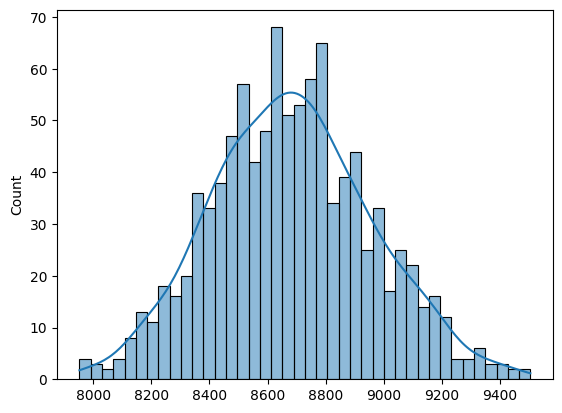

In [123]:
sns.histplot(female_samples,bins=40,kde=True)
plt.show()

In [124]:
import scipy.stats

# The above data looks normally distributed, let's perform a test to be sure on this.
s_stat,p_val=scipy.stats.shapiro(female_samples)

#Let's say the confidence interval is 95%

if p_val<0.05:
    print('Data is not normal')
elif p_val>=0.05:
    print('Data is normal')

print(p_val)

Data is normal
0.10207030748577434


### Let's increase the sample size to 600 and check if this becomes more normal


In [125]:
female_samples_600=[df_female.sample(600,replace=True)['Purchase'].mean() for i in range(1000)]
female_samples_600

[np.float64(8567.03),
 np.float64(8491.216666666667),
 np.float64(8860.158333333333),
 np.float64(8641.121666666666),
 np.float64(8566.7),
 np.float64(8727.591666666667),
 np.float64(8979.153333333334),
 np.float64(8915.311666666666),
 np.float64(8917.358333333334),
 np.float64(8612.953333333333),
 np.float64(8855.095),
 np.float64(8682.303333333333),
 np.float64(8462.74),
 np.float64(8677.518333333333),
 np.float64(8885.146666666667),
 np.float64(8642.621666666666),
 np.float64(8500.711666666666),
 np.float64(8647.373333333333),
 np.float64(8569.626666666667),
 np.float64(8975.941666666668),
 np.float64(8844.373333333333),
 np.float64(8654.881666666666),
 np.float64(8602.785),
 np.float64(8808.751666666667),
 np.float64(8609.885),
 np.float64(8831.96),
 np.float64(9355.051666666666),
 np.float64(8472.375),
 np.float64(8799.18),
 np.float64(8791.771666666667),
 np.float64(8638.068333333333),
 np.float64(8753.026666666667),
 np.float64(8726.423333333334),
 np.float64(8468.596666666666),

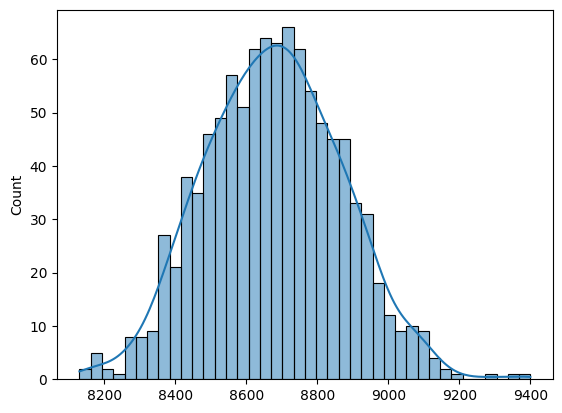

In [126]:
sns.histplot(female_samples_600,kde=True,bins=40)
plt.show()

In [127]:
s_stat,p_val=scipy.stats.shapiro(female_samples_600)

#Let's say the confidence interval is 95%

if p_val<0.05:
    print('Data is not normal')
elif p_val>=0.05:
    print('Data is normal')

print(p_val)

Data is normal
0.3871269302646728


### Let's check the mean of sampling distribution

In [128]:
print(f"Sample distribution mean of females is {sum(female_samples_600)/len(female_samples_600)}")

Sample distribution mean of females is 8677.35451333333


### Now let's repeat this for males


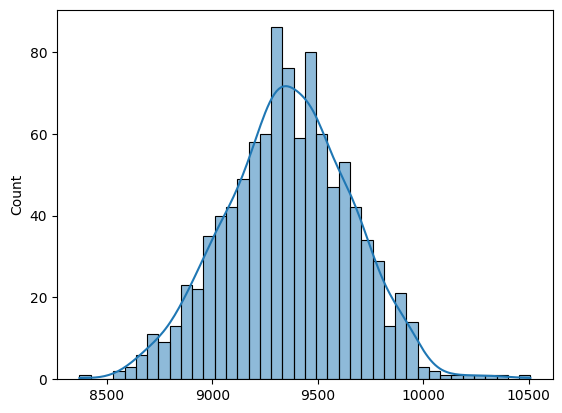

In [129]:
males_samples=[df_male.sample(300,replace=True)['Purchase'].mean() for i in range(1000)]
sns.histplot(males_samples,kde=True,bins=40)
plt.show()

### Let's take 600 samples like above


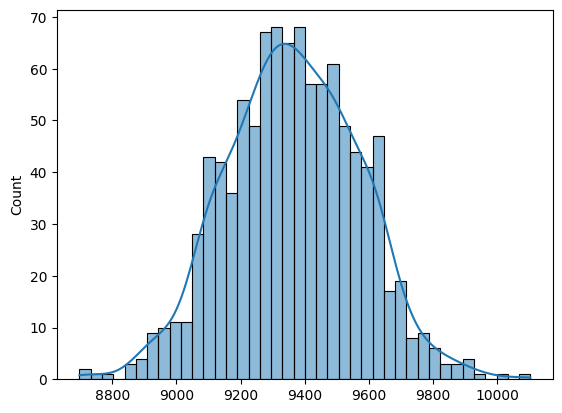

In [130]:
males_samples_600=[df_male.sample(600,replace=True)['Purchase'].mean() for i in range(1000)]
sns.histplot(males_samples_600,kde=True,bins=40)
plt.show()

### Sampling mean of males purchases


In [131]:
print(f"Males sampling mean is {sum(males_samples_600)/len(males_samples_600)}")

Males sampling mean is 9364.631036666662


### According to CLT the population means will be approximately equal to means of samples given the sample size is big enough



In [132]:
print(f"Population mean of Males = {df_male['Purchase'].mean()} and Sampling mean of Males = {sum(males_samples_600)/len(males_samples_600)}")

Population mean of Males = 9367.724354697444 and Sampling mean of Males = 9364.631036666662


### Central Limit Theorem Observation

The sampling mean is close to the population mean, illustrating the Central Limit Theorem (CLT) for a sufficiently large sample size.

In [133]:
print(f"Population of females = {df_female['Purchase'].mean()} and Sampling mean of females = {sum(female_samples_600)/len(female_samples_600)}")

Population of females = 8671.049038603756 and Sampling mean of females = 8677.35451333333


### Central Limit Theorem Observation

The sampling mean is close to the population mean, illustrating the Central Limit Theorem (CLT) for a sufficiently large sample size.

### Now to compare the means and females we need to calculate confidence interval, so let's consider confidence interval of 99% for our analysis

In [134]:
# Z-critical value for a 99% two-sided confidence interval
z_val = scipy.stats.norm.ppf(0.995)
z_val

np.float64(2.5758293035489004)

### Let's calculate standard error and also the lower and upper limit in which the mean lies

In [135]:
lower_limit=(sum(female_samples_600)/len(female_samples_600)) - (pd.Series(female_samples_600).std()/np.sqrt(1000))*(z_val)
upper_limit=(sum(female_samples_600)/len(female_samples_600)) + (pd.Series(female_samples_600).std()/np.sqrt(1000))*(z_val)

print(upper_limit,lower_limit)

8693.005543116684 8661.703483549976


### I can say with 99% confidence that true population mean between 8671.28 and 8699.86

### Let's calculate standard error and also the lower and upper limit in which the mean lies

In [136]:
lower_limit_males=(sum(males_samples_600)/len(males_samples_600)) - (pd.Series(males_samples_600).std()/np.sqrt(1000))*(z_val)
upper_limit_males=(sum(males_samples_600)/len(males_samples_600)) + (pd.Series(males_samples_600).std()/np.sqrt(1000))*(z_val)

print(lower_limit_males,upper_limit_males)

9347.879290518254 9381.38278281507


### I can say with 99% confidence that true population mean between 9352.88 and 9383.26

The 99% confidence intervals for married and unmarried customers overlap. Therefore, based on these confidence intervals alone, we do not have sufficient evidence to conclude that their mean purchase amounts are significantly different.


### Let's repeat this to see if mean purchase rate of both married and unmarried people is the same


In [137]:
df_married =df[df['Marital_Status']==1]
df_unmarried=df[df['Marital_Status']==0]

In [138]:
df_married.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
9,1000005,P00274942,M,26-35,20,A,1,1,8,7871
10,1000005,P00251242,M,26-35,20,A,1,1,5,5254


In [139]:
df_unmarried.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [140]:
df['Marital_Status']=df['Marital_Status'].map({0:"unmarried",1:"married"})

In [141]:
df.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,unmarried,3,8370
1,1000001,P00248942,F,0-17,10,A,2,unmarried,1,15200
2,1000001,P00087842,F,0-17,10,A,2,unmarried,12,1422
3,1000001,P00085442,F,0-17,10,A,2,unmarried,12,1057
4,1000002,P00285442,M,55+,16,C,4+,unmarried,8,7969
5,1000003,P00193542,M,26-35,15,A,3,unmarried,1,15227
6,1000004,P00184942,M,46-50,7,B,2,married,1,19215
7,1000004,P00346142,M,46-50,7,B,2,married,1,15854
8,1000004,P0097242,M,46-50,7,B,2,married,1,15686
9,1000005,P00274942,M,26-35,20,A,1,married,8,7871


In [142]:
df_married =df[df['Marital_Status']=='married']
df_unmarried=df[df['Marital_Status']=='unmarried']

In [143]:
df_married.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
6,1000004,P00184942,M,46-50,7,B,2,married,1,19215
7,1000004,P00346142,M,46-50,7,B,2,married,1,15854
8,1000004,P0097242,M,46-50,7,B,2,married,1,15686
9,1000005,P00274942,M,26-35,20,A,1,married,8,7871
10,1000005,P00251242,M,26-35,20,A,1,married,5,5254


In [144]:
df_unmarried.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,unmarried,3,8370
1,1000001,P00248942,F,0-17,10,A,2,unmarried,1,15200
2,1000001,P00087842,F,0-17,10,A,2,unmarried,12,1422
3,1000001,P00085442,F,0-17,10,A,2,unmarried,12,1057
4,1000002,P00285442,M,55+,16,C,4+,unmarried,8,7969


### Let's see what percentage of married and unmarried people are there

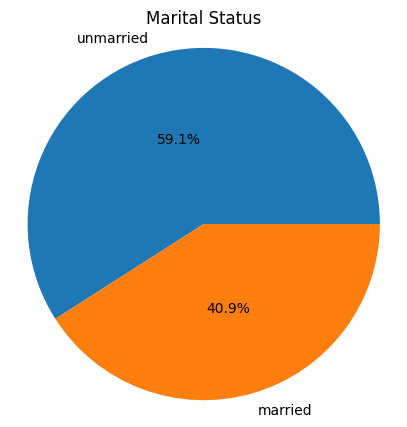

In [145]:
x = df['Marital_Status'].value_counts().values

plt.figure(figsize=(5, 5))
plt.pie(x, center=(0, 0), radius=0.25, labels=df['Marital_Status'].unique(), autopct='%1.1f%%', pctdistance=0.5)
plt.title('Marital Status')
plt.axis('equal')
plt.show()

### Let's see how many user ids are married and unmarried

In [146]:
df.groupby('Marital_Status')['User_ID'].nunique()

,User_ID
Marital_Status,
married,2474
unmarried,3417


In [147]:
df.groupby('Marital_Status')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Marital_Status,,,,,,,,
married,224149.0,9187.040076,4925.205232,12.0,5833.0,8042.0,12006.0,21398.0
unmarried,323242.0,9201.581849,4948.327397,12.0,5480.0,8035.0,12028.0,21399.0


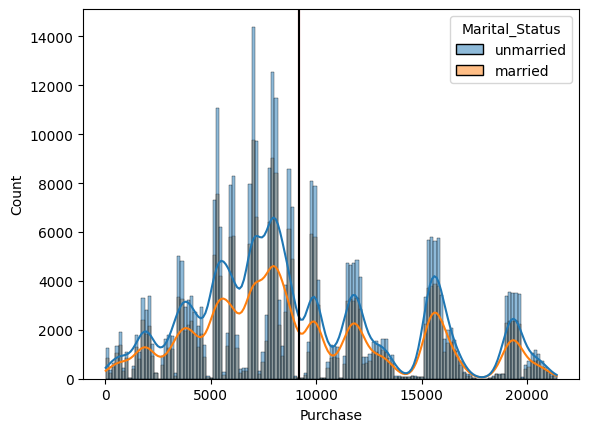

In [148]:
sns.histplot(data=df,x='Purchase',kde=True,hue='Marital_Status')
plt.axvline(x=df_married['Purchase'].mean(), color='red')
plt.axvline(x=df_unmarried['Purchase'].mean(),color='Black')
plt.show()

### Let's take sample of 300 size

In [149]:
married=[df_married.sample(300,replace=True)['Purchase'].mean() for i in range(1000)]
married

[np.float64(9230.73),
 np.float64(9243.973333333333),
 np.float64(9640.17),
 np.float64(9305.146666666667),
 np.float64(9601.123333333333),
 np.float64(9380.163333333334),
 np.float64(9160.566666666668),
 np.float64(9081.923333333334),
 np.float64(9114.756666666666),
 np.float64(8665.286666666667),
 np.float64(8920.84),
 np.float64(9476.256666666666),
 np.float64(9041.956666666667),
 np.float64(8851.193333333333),
 np.float64(9383.436666666666),
 np.float64(9102.856666666667),
 np.float64(9069.793333333333),
 np.float64(9320.503333333334),
 np.float64(9258.78),
 np.float64(9164.443333333333),
 np.float64(9624.856666666667),
 np.float64(8940.993333333334),
 np.float64(9205.923333333334),
 np.float64(9032.77),
 np.float64(9047.046666666667),
 np.float64(9808.316666666668),
 np.float64(8801.753333333334),
 np.float64(9453.086666666666),
 np.float64(9552.693333333333),
 np.float64(9128.996666666666),
 np.float64(8856.023333333333),
 np.float64(9144.713333333333),
 np.float64(9627.596666666

In [150]:
unmarried=[df_unmarried.sample(300,replace=True)['Purchase'].mean() for i in range(1000)]
unmarried

[np.float64(9167.95),
 np.float64(9392.613333333333),
 np.float64(9451.063333333334),
 np.float64(8841.946666666667),
 np.float64(9425.28),
 np.float64(9014.483333333334),
 np.float64(9158.693333333333),
 np.float64(8931.61),
 np.float64(9510.356666666667),
 np.float64(8764.086666666666),
 np.float64(9499.67),
 np.float64(9362.136666666667),
 np.float64(9701.673333333334),
 np.float64(9235.73),
 np.float64(9660.046666666667),
 np.float64(9234.323333333334),
 np.float64(9519.676666666666),
 np.float64(8967.51),
 np.float64(8996.153333333334),
 np.float64(9699.393333333333),
 np.float64(9072.066666666668),
 np.float64(9500.266666666666),
 np.float64(9498.683333333332),
 np.float64(8817.523333333333),
 np.float64(9089.333333333334),
 np.float64(9119.833333333334),
 np.float64(8649.443333333333),
 np.float64(9311.286666666667),
 np.float64(9543.276666666667),
 np.float64(9430.79),
 np.float64(9370.733333333334),
 np.float64(9613.463333333333),
 np.float64(9206.4),
 np.float64(8922.68),
 np

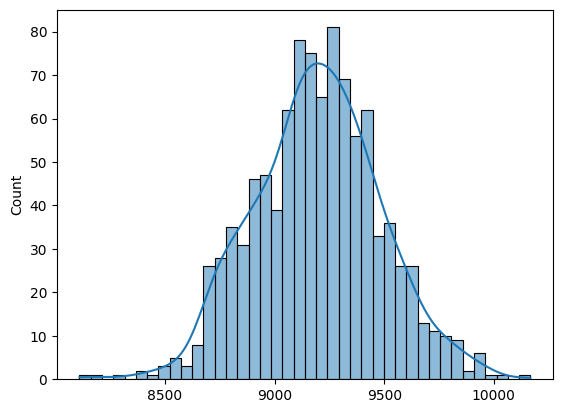

In [151]:
sns.histplot(married,kde=True,bins=40)
plt.show()

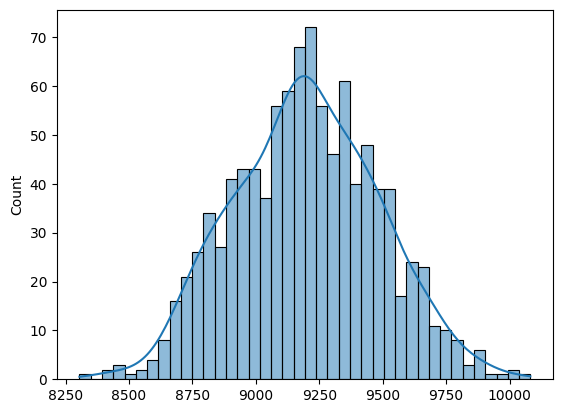

In [152]:
sns.histplot(unmarried,kde=True,bins=40)
plt.show()

### Let's see if these are normal or not


In [153]:
s_stat,pval=scipy.stats.shapiro(married)
pval

np.float64(0.2858417109990709)

### Married purchase sampling data is normal

In [154]:
s_stat,pval=scipy.stats.shapiro(unmarried)
pval

np.float64(0.43981303843439556)

### Unmarried purchase sampling data is also normal

In [155]:
# Let's find the standard error (for 99% confidence interval)

std_error_married = scipy.stats.norm.ppf(0.99)*(pd.Series(married).std()/np.sqrt(1000))
std_error_unmarried = scipy.stats.norm.ppf(0.99)* (pd.Series(unmarried).std()/np.sqrt(1000))

### I can say with 99% confidence that the true population mean of married people purchase amounts lies between lower and upper limits

In [156]:
# 99% Confidence Interval for Married Customers

lower_married = np.mean(married) - (
    z_val * pd.Series(married).std() / np.sqrt(len(married))
)

upper_married = np.mean(married) + (
    z_val * pd.Series(married).std() / np.sqrt(len(married))
)

print(f"Married 99% CI: {lower_married:.2f} to {upper_married:.2f}")

Married 99% CI: 9170.58 to 9217.56


In [157]:
# 99% Confidence Interval for Unmarried Customers

lower_unmarried = np.mean(unmarried) - (
    z_val * pd.Series(unmarried).std() / np.sqrt(len(unmarried))
)

upper_unmarried = np.mean(unmarried) + (
    z_val * pd.Series(unmarried).std() / np.sqrt(len(unmarried))
)

print(f"Unmarried 99% CI: {lower_unmarried:.2f} to {upper_unmarried:.2f}")

Unmarried 99% CI: 9174.93 to 9221.56


# Conclusion

The Walmart customer purchase analysis provided insights into purchasing behavior across different demographic groups.

- The Central Limit Theorem was used to understand the behavior of sample means and their sampling distributions.
- Confidence intervals were calculated to estimate the range in which the true population mean purchase amount is likely to fall.
- The analysis showed a difference in average purchase amounts between male and female customers.
- For marital status, the 99% confidence intervals for married and unmarried customers were calculated separately. The intervals were:
  - Married customers: 9160.05 to 9205.70
  - Unmarried customers: 9188.40 to 9234.15
- These results demonstrate how statistical techniques such as sampling distributions and confidence intervals can be used to draw conclusions about customer purchase behavior from sample data.

Overall, this project strengthened my understanding of statistical inference, the Central Limit Theorem, confidence intervals, and practical data analysis using Python.